In [37]:
import pandas as pd

In [38]:
df = pd.read_csv('ecommerce_sales.csv')

In [39]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount,Sales,Profit,City,State,Payment_Mode
0,ORD0001,2026-05-02,CUST0215,Jeans,Clothing,3,3032.05,10,8186.54,2025.07,Pune,Maharashtra,UPI
1,ORD0002,2026-06-07,CUST0294,Smartwatch,Electronics,3,4714.44,0,14143.32,1931.35,Lucknow,Uttar Pradesh,UPI
2,ORD0003,2026-02-28,CUST0170,Laptop,Electronics,2,55648.48,0,111296.96,10139.93,Gurugram,Haryana,UPI
3,ORD0004,2026-03-05,CUST0131,Face Wash,Beauty,2,401.30,10,722.34,179.83,Pune,Maharashtra,Net Banking
4,ORD0005,2026-01-09,CUST0053,Jeans,Clothing,3,1592.21,0,4776.63,1345.67,Mumbai,Maharashtra,UPI


In [40]:
df.shape

(1000, 13)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      1000 non-null   object 
 1   Order_Date    1000 non-null   object 
 2   Customer_ID   1000 non-null   object 
 3   Product       1000 non-null   object 
 4   Category      1000 non-null   object 
 5   Quantity      1000 non-null   int64  
 6   Unit_Price    1000 non-null   float64
 7   Discount      1000 non-null   int64  
 8   Sales         1000 non-null   float64
 9   Profit        1000 non-null   float64
 10  City          1000 non-null   object 
 11  State         1000 non-null   object 
 12  Payment_Mode  1000 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 101.7+ KB


In [42]:
df.describe()

,Quantity,Unit_Price,Discount,Sales,Profit
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,2.479000,8309.418690,7.63500,18962.524720,2834.63300
std,1.112113,14965.151161,5.70213,37777.842922,4275.97409
min,1.000000,250.800000,0.00000,243.920000,63.75000
25%,1.000000,1840.152500,5.00000,3389.170000,722.38000
50%,2.000000,3174.935000,5.00000,6610.720000,1438.46000
75%,3.000000,5955.322500,10.00000,14143.380000,2943.73000
max,4.000000,79196.110000,20.00000,285106.000000,35652.69000


In [43]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Product,0
Category,0
Quantity,0
Unit_Price,0
Discount,0
Sales,0
Profit,0


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [46]:
total_revenue = df['Sales'].sum()
print(total_revenue)

18962524.72


In [47]:
total_profit = df['Profit'].sum()
print(total_profit)

2834633.0


In [48]:
total_orders = df['Order_ID'].nunique()
print(total_orders)

1000


In [49]:
total_orders = df['Quantity'].sum()
print(total_orders)

2479


In [50]:
product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
print(product_sales.head(10))

Product
Laptop          6145661.91
Smartphone      4729183.90
Smartwatch      1399354.58
Office Chair    1180039.32
Sneakers         709079.37
Perfume          675809.25
Coffee Maker     531860.55
Cookware Set     505130.30
Headphones       467250.40
Jacket           378083.12
Name: Sales, dtype: float64


<Axes: xlabel='Product'>

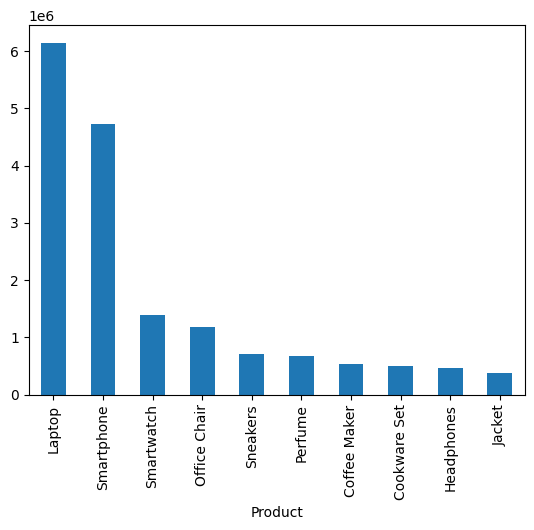

In [51]:
product_sales.head(10).plot(kind='bar')

In [52]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Beauty          1631613.81
Clothing        1682093.37
Electronics    13039252.19
Home            2609565.35
Name: Sales, dtype: float64


<Axes: xlabel='Category'>

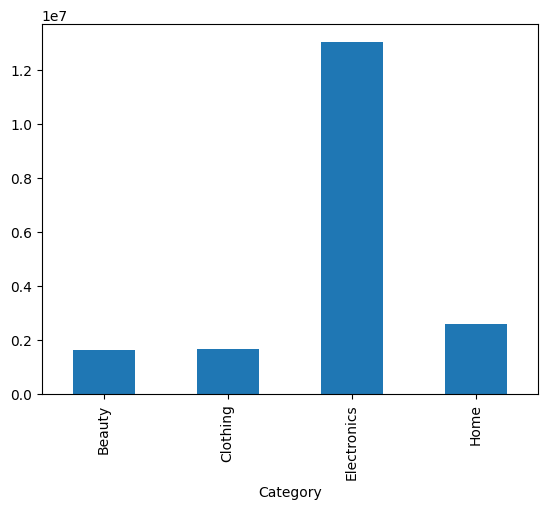

In [53]:
category_sales.head(10).plot(kind='bar')

In [54]:
df['Month'] = df['Order_Date'].dt.to_period('M')


In [55]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
2026-01    3186728.68
2026-02    2600147.53
2026-03    2033722.94
2026-04    2695650.44
2026-05    2159050.50
2026-06    2588778.03
2026-07    2699198.42
2026-08     999248.18
Freq: M, Name: Sales, dtype: float64


<Axes: xlabel='Month'>

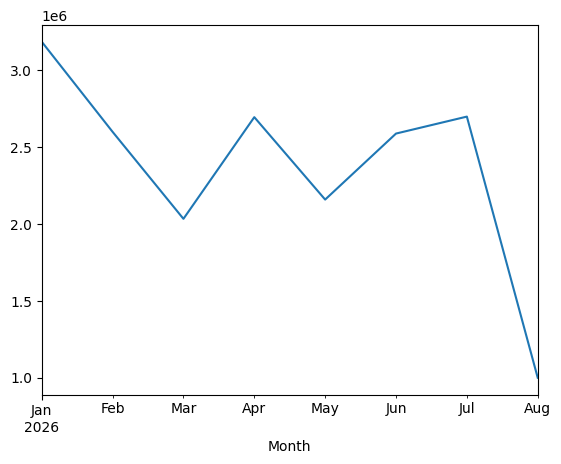

In [56]:
monthly_sales.plot(kind='line')

In [57]:
city_sales = (
    df.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(city_sales.head(10))

City
Pune         2208287.19
Mumbai       2041058.82
Lucknow      1720819.49
Gurugram     1704052.87
Chennai      1677264.50
Jaipur       1638329.61
Ahmedabad    1567045.78
Delhi        1556966.99
Kolkata      1470825.76
Hyderabad    1366846.90
Name: Sales, dtype: float64


In [58]:
product_profit = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(product_profit.head(10))

Product
Laptop          692549.96
Smartphone      535842.41
Office Chair    226817.08
Perfume         189095.62
Sneakers        170437.40
Smartwatch      157864.36
Makeup Kit      106317.50
Coffee Maker    101733.36
Cookware Set     95198.84
Jacket           90787.52
Name: Profit, dtype: float64


In [59]:
customer_sales = (
    df.groupby("Customer_ID")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_sales.head(10))

Customer_ID
CUST0015    394672.74
CUST0028    380594.59
CUST0206    380058.88
CUST0126    338483.19
CUST0226    325173.29
CUST0293    308006.46
CUST0267    300917.09
CUST0117    295555.04
CUST0038    282806.99
CUST0137    281993.99
Name: Sales, dtype: float64


In [60]:
payment = df.groupby("Payment_Mode")["Sales"].sum()

print(payment)

Payment_Mode
Cash           1597021.31
Credit Card    4425228.75
Debit Card     3358757.53
Net Banking    3466701.73
UPI            6114815.40
Name: Sales, dtype: float64
